##  Data Understanding

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [ ]:
import gzip
import pandas as pd
import ast
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import zipfile
import warnings

warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.formatwarning = lambda message, category, filename, lineno, line=None: ''

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/archive.zip /content

In [ ]:
!unzip /content/archive.zip -d/content/dataSet

Archive:  /content/archive.zip
  inflating: /content/dataSet/01012023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01022023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01032023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01042023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01052023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01062023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01072023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01082023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01092023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01102023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01112023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01122023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01132023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01142023_BreakingNews.csv.gzip  
  inflating: /content/dataSet/01152023_BreakingNews.csv.gzip  
  inflating: /content/da

In [ ]:
import gzip
import pandas as pd
import os

# List of paths to .gzip files
gzip_file_paths = [
    '/content/dataSet/01012023_BreakingNews.csv.gzip',
    '/content/dataSet/01022023_BreakingNews.csv.gzip',
    '/content/dataSet/01032023_BreakingNews.csv.gzip',
    '/content/dataSet/01042023_BreakingNews.csv.gzip',
    '/content/dataSet/01052023_BreakingNews.csv.gzip',
    '/content/dataSet/01062023_BreakingNews.csv.gzip',
    '/content/dataSet/01072023_BreakingNews.csv.gzip'
]

# Process each gzip file
for file_path in gzip_file_paths:
    # Read the gzip file and load as DataFrame
    with gzip.open(file_path, 'rb') as f:
        df = pd.read_csv(f)

    # Display results
    print(f"Data from: {file_path}")
    print(df.head())
    print(df['hashtags'])
    print("-" * 80)

Data from: /content/dataSet/01012023_BreakingNews.csv.gzip
   Unnamed: 0         hashed_userid  masked_username  \
0           0  62408197342966653094       *****urope   
1           1  39767155595304285205          ****sAU   
2           2  28072988318506185830  ********nTenAss   
3           3  43664487890167532123    *******chaelj   
4           4     24519376910836844    *******ngNews   

                         location  following  followers  totaltweets  \
0                          Europe        218      15794        39405   
1           Australia & the World        403      22939        14614   
2  International 25K Readers/plus        457        465         6203   
3                     Los Angeles        245        405        27127   
4                   United States         97       1123         9710   

  usercreateddt  verified              tweetid       tweetcreatedts  \
0    2016-12-30      True  1609338622121058305  2023-01-01 00:00:02   
1    2020-04-29      True  16

## Data Preparation (Data Transformation)

In [ ]:
import ast

# Convert the string representation of lists into actual lists
df["hashtags"] = df["hashtags"].apply(ast.literal_eval)

# Extract the hashtag text
df["hashtags"] = df["hashtags"].apply(lambda x: [tag["text"] for tag in x])

# Debug: Print sample hashtags
print("Sample hashtags:")
print(df["hashtags"].head())

Sample hashtags:
0    [blackmedia, localnews, community, scoop, news...
1    [realnews, news, AI, Oigetit, Toddler, Trauma,...
2              [Trending, News, Topics, Entertainment]
3    [trucking, trucks, truckie, business, fuel, ta...
4    [trending, dreams, gratitude, nevergiveup, sel...
Name: hashtags, dtype: object


## Data Cleaning

In [ ]:
# Clean the hashtags
df["hashtags"] = df["hashtags"].apply(lambda x: [tag.lower().strip() for tag in x if tag.strip()])

In [ ]:
# Debug: Print cleaned hashtags
print("Cleaned hashtags:")
print(df["hashtags"].head())

Cleaned hashtags:
0    [blackmedia, localnews, community, scoop, news...
1    [realnews, news, ai, oigetit, toddler, trauma,...
2              [trending, news, topics, entertainment]
3    [trucking, trucks, truckie, business, fuel, ta...
4    [trending, dreams, gratitude, nevergiveup, sel...
Name: hashtags, dtype: object


## Data Filtering

In [ ]:
df = df.drop_duplicates(subset="hashtags", keep=False).reset_index(drop=True)

In [ ]:
# Filter out tweets with no hashtags
df = df[df["hashtags"].apply(len) > 0]

# Debug: Print the number of tweets after filtering
print("Number of tweets after filtering:", len(df))
# print(df["hashtags"])


# Set display option to show all rows
import pandas as pd
pd.set_option('display.max_rows', None)

# Now print all hashtags
print(df["hashtags"])

# Reset to default
pd.reset_option('display.max_rows')

Streaming output truncated to the last 5000 lines.
4618    [behinderung, inklusion, deutschland, hilfe, n...
4619    [train, women, driver, haramain, makkah, trend...
4620                   [news, allaboutnewport, eyehealth]
4621    [potd, love, karishmatanna, instagram, gujarat...
4622    [아스트로, news, astro, 문빈_산하, moonbin_sanha, 문빈, ...
4623    [breakingnews, டெல்டாமலர், newspaper, todaynew...
4624    [chhattisgarh, chhattisgarhnews, chhattisgarhu...
4625    [पेण्ड्रा, chhattisgarhwithnews18, breakingnew...
4626    [totp, bbcbreakfast, media, sotlive, music, mo...
4627                                   [trending, suabot]
4628    [georginanjenga, lgbtq, music, contentcreator,...
4629    [airlanggahartarto, golkarindonesia, news, vir...
4630    [juvenile, jerseyshorevibe, review, season, tr...
4631                         [breakingnews, giletsjaunes]
4632    [beirut24, lebanon, news, اخبار, انتخاب_رئيس_ج...
4633                [akhabar, joshimath, news, badrinath]
4634    [winfair, fac

## Text Preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if not found
try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords')
    stop_words = set(stopwords.words('english'))

# Remove stopwords from hashtags
df["hashtags"] = df["hashtags"].apply(lambda x: [tag for tag in x if tag not in stop_words])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Debug: Print hashtags after stop word removal
print("Hashtags after stop word removal:")
print(df["hashtags"].head())

Hashtags after stop word removal:
0    [blackmedia, localnews, community, scoop, news...
1    [realnews, news, ai, oigetit, toddler, trauma,...
2    [trucking, trucks, truckie, business, fuel, ta...
3    [trending, dreams, gratitude, nevergiveup, sel...
4                                    [fairtrade, news]
Name: hashtags, dtype: object


## Stemming and Unwanted Word Removal


In [ ]:
!pip install langdetect

from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def is_english(text):
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False  # In case of empty or weird text

df = df[df["text"].apply(is_english)].reset_index(drop=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=9e8c7fd18032b37a5b81be3add8b1b96b71eb19e7fbee4ce6bbd0494988fd70e
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
# Set display option to show all rows
import pandas as pd
pd.set_option('display.max_rows', None)

# Now print all hashtags
print(df["hashtags"])

# Reset to default
pd.reset_option('display.max_rows')

0       [blackmedia, localnews, community, scoop, news...
1       [realnews, news, ai, oigetit, toddler, trauma,...
2       [trucking, trucks, truckie, business, fuel, ta...
3       [trending, dreams, gratitude, nevergiveup, sel...
4                                       [fairtrade, news]
5       [life, truth, gabrielofurantia, getrealordietr...
6       [prescottnews, prescott, prescottsports, arizo...
7       [unicorn, breaking, topstartups, breaking, tec...
8       [winter, snow, darkness, maveric, socialmedias...
9       [nfl, touchdown, news, sports, clevelandbrowns...
10      [marvel, marvelcomics, comics, comicbooks, new...
11      [ada, btc, crypto, metaverse, web3, cryptonews...
12                  [bakedbeans2_0, trending, dapp, defi]
13      [altcoinsnews, btc, crypto, metaverse, web3, c...
14      [cybersecurity, practices, security, business,...
15      [fringefm, fringe, latenighttalk, dreams, real...
16      [virginia, police, school, shooting, breaking,...
17      [mccar

In [ ]:
# Stemming
stemmer = PorterStemmer()
df["hashtags"] = df["hashtags"].apply(lambda x: [stemmer.stem(tag) for tag in x])

In [ ]:
# Debug: Print hashtags after stemming
print("Hashtags after stemming:")
print(df["hashtags"].head())

Hashtags after stemming:
0    [blackmedia, localnew, commun, scoop, news, af...
1    [realnew, news, ai, oigetit, toddler, trauma, ...
2    [truck, truck, trucki, busi, fuel, taxcredit, ...
3    [trend, dream, gratitud, nevergiveup, selflov,...
4                                     [fairtrad, news]
Name: hashtags, dtype: object


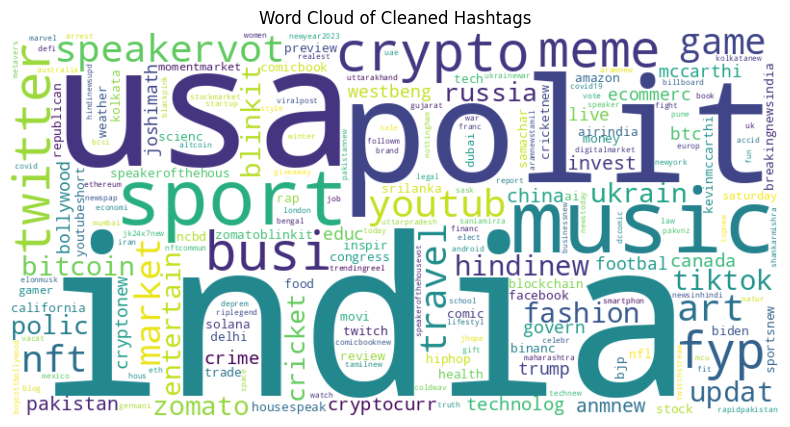

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Define your list of useless words (may not be removed)
useless_words = [
    'love', 'like', 'new', 'news', 'latest', 'video', 'follow', 'life', 'quot',
    'tweet', 'foryou', 'foryoupag', 'likeforlik', 'like4lik', 'win', 'fire',
    'photo', 'photooftheday', 'photographi', 'artist', 'podcast', 'info',
    'shop', 'instagood', 'media', 'explor', 'explorepag', 'reel', 'short',
    'dailynew', 'dailynewsupd', 'todaynew', 'latestupd', 'newsintweetsindia',
    'newsintweetsin', 'newsintweet', 'newsbreak', 'world', 'indian',
    'america', 'us', 'motiv', 'funni', 'comedi', 'socialmedia',
    'importentnew', 'importantnew', 'headlin', 'newsalert', 'addtocart',
    'bengalinewsl', 'banglanew', 'bengalinew', 'web3', 'beauti', 'design',
    'shopifi', 'anim', 'instagram', 'breakingnew', 'break', 'latestnew',
    'newsupd', 'trendingnew','viral','trend','trendingnow', 'trendingvideo', 'todaynew', 'livenew',
    'worldnew', 'latestupd', 'breaking_new','viralvideo','trendingnewstoday','currentaffair'
]

# Clean hashtags
df["hashtags"] = df["hashtags"].apply(
    lambda x: [tag for tag in x if tag not in useless_words]
)

all_hashtags_text = " ".join([" ".join(tags) for tags in df["hashtags"]])

# 2. Generate the word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',  # You can change the color map
    collocations=False  # Prevents grouping common word pairs
).generate(all_hashtags_text)

# 3. Display the generated image
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hide the axes
plt.title("Word Cloud of Cleaned Hashtags")
plt.show()

In [53]:
# TF-IDF Weighting
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['hashtags'].apply(lambda x: ' '.join(x)))

# Debug: Print TF-IDF matrix
print("TF-IDF Matrix:")
print(tfidf_matrix.shape)

TF-IDF Matrix:
(6652, 16066)


Clusters:
cluster
0    6479
4     167
1       3
3       2
2       1
Name: count, dtype: int64


In [55]:
# Prepare transactions for Apriori
transactions = df["hashtags"].tolist()

# Debug: Print sample transactions
print("Sample transactions:")
print(transactions[:5])

Sample transactions:
[['blackmedia', 'localnew', 'commun', 'scoop', 'africanamerican', 'philadelphia', 'scoopusamedia', 'philli', 'scoopusa', 'subscrib'], ['realnew', 'ai', 'oigetit', 'toddler', 'trauma', 'food'], ['truck', 'truck', 'trucki', 'busi', 'fuel', 'taxcredit', 'updat'], ['dream', 'gratitud', 'nevergiveup', 'selflov', 'inspir'], ['fairtrad']]


In [56]:
import nltk
from nltk.corpus import words
nltk.download('words')

# English words set
english_words = set(words.words())

# Prepare transactions with English-only hashtags
transactions = df["hashtags"].apply(
    lambda tags: [tag for tag in tags if tag.lower() in english_words]
).tolist()

# Debug: Print sample transactions
print("Sample filtered transactions:", transactions[:5])

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


Sample filtered transactions: [['scoop'], ['ai', 'toddler', 'trauma', 'food'], ['truck', 'truck', 'fuel'], ['dream'], []]


## **Apriori Computation**

In [57]:
# Import necessary libraries
import pandas as pd
import numpy as np
from collections import defaultdict
import time
import matplotlib.pyplot as plt
from itertools import combinations

In [58]:
def find_frequent_1_itemsets(transactions, min_support):
    """
    Find all frequent 1-itemsets (single items) that meet the minimum support threshold.

    Parameters:
    transactions (list of lists): List of transactions, where each transaction is a list of items
    min_support (float): Minimum support threshold (as a fraction of total transactions)

    Returns:
    dict: Dictionary with items as keys and their support as values
    """
    # Count occurrences of each item
    item_counts = defaultdict(int)
    total_transactions = len(transactions)

    # Iterate through each transaction
    for transaction in transactions:
        # Count each unique item in the transaction
        for item in set(transaction):
            item_counts[item] += 1

    # Filter items based on minimum support
    frequent_items = {item: count/total_transactions
                     for item, count in item_counts.items()
                     if count/total_transactions >= min_support}


    print(f"Found {len(frequent_items)} frequent 1-itemsets")
    return frequent_items

In [59]:
def generate_candidates(frequent_items_prev, k):
    """
    Generate candidate k-itemsets from frequent (k-1)-itemsets.

    Parameters:
    frequent_items_prev (dict): Dictionary of frequent (k-1)-itemsets with their support
    k (int): Size of itemsets to generate

    Returns:
    list: List of candidate k-itemsets (each itemset is represented as a frozenset)
    """
    # Get the frequent (k-1)-itemsets
    prev_itemsets = list(frequent_items_prev.keys())

    # Generate candidates using the join step
    candidates = []

    for i in range(len(prev_itemsets)):
        for j in range(i+1, len(prev_itemsets)):
            # For k=2, each itemset is a single item, so we need to handle it differently
            if k == 2:
                # Create a new candidate by merging two frequent 1-itemsets
                candidate = frozenset([prev_itemsets[i], prev_itemsets[j]])
                candidates.append(candidate)
            else:
                # For k>2, each itemset is already a frozenset
                # To join, we need the first k-2 items to be the same
                itemset1 = list(prev_itemsets[i])
                itemset2 = list(prev_itemsets[j])
                itemset1.sort()
                itemset2.sort()

                # Check if first k-2 items are the same
                if itemset1[:-1] == itemset2[:-1]:
                    # Generate new candidate
                    candidate = frozenset(list(prev_itemsets[i]) + [itemset2[-1]])

                    # Prune step: check if all (k-1) subsets of the candidate are frequent
                    should_prune = False
                    for item in candidate:
                        subset = frozenset([x for x in candidate if x != item])
                        if k > 2 and subset not in prev_itemsets:
                            should_prune = True
                            break

                    if not should_prune:
                        candidates.append(candidate)

    return candidates

In [60]:
def count_support(candidates, transactions, min_support):
    """
    Count the support for each candidate itemset and filter those meeting minimum support.

    Parameters:
    candidates (list): List of candidate itemsets
    transactions (list of lists): List of transactions
    min_support (float): Minimum support threshold

    Returns:
    dict: Dictionary of frequent itemsets with their support values
    """
    # Dictionary to store counts
    itemset_counts = defaultdict(int)
    total_transactions = len(transactions)

    # Count occurrences of each candidate itemset
    for transaction in transactions:
        transaction_set = set(transaction)
        for candidate in candidates:
            # For k=2, candidate is a frozenset containing two strings
            # For k>2, candidate is a frozenset of items
            if isinstance(list(candidate)[0], str):
                # k=2 case: Check if both items exist in the transaction
                if all(item in transaction_set for item in candidate):
                    itemset_counts[candidate] += 1
            else:
                # k>2 case: Check if all items in the candidate exist in the transaction
                if candidate.issubset(transaction_set):
                    itemset_counts[candidate] += 1

    # Filter itemsets based on minimum support
    frequent_itemsets = {itemset: count/total_transactions
                         for itemset, count in itemset_counts.items()
                         if count/total_transactions >= min_support}

    return frequent_itemsets

In [61]:
def apriori(transactions, min_support=0.01, max_length=None):
    """
    Implementation of the Apriori algorithm to find frequent itemsets.

    Parameters:
    transactions (list of lists): List of transactions
    min_support (float): Minimum support threshold
    max_length (int, optional): Maximum length of itemsets to find

    Returns:
    dict: Dictionary with keys as lengths and values as dictionaries of itemsets with their support
    """
    # Find frequent 1-itemsets
    frequent_1_itemsets = find_frequent_1_itemsets(transactions, min_support)

    # Initialize the result with frequent 1-itemsets
    frequent_itemsets = {1: frequent_1_itemsets}
    k = 2

    # Continue until no more frequent itemsets are found or max_length is reached
    while k <= (max_length if max_length else float('inf')):
        print(f"Finding frequent {k}-itemsets...")

        # Get frequent (k-1)-itemsets
        prev_frequent = frequent_itemsets[k-1]

        if not prev_frequent:
            # If no frequent (k-1)-itemsets, then no frequent k-itemsets
            break

        # Generate candidate k-itemsets
        candidates = generate_candidates(prev_frequent, k)

        if not candidates:
            # If no candidates, then no frequent k-itemsets
            break

        # Get frequent k-itemsets
        frequent_k = count_support(candidates, transactions, min_support)

        print(f"Found {len(frequent_k)} frequent {k}-itemsets")

        # If no frequent k-itemsets are found, stop
        if not frequent_k:
            break

        # Add frequent k-itemsets to the result
        frequent_itemsets[k] = frequent_k

        # Move to next k
        k += 1

        # Break if max_length is reached
        if max_length and k > max_length:
            break

    return frequent_itemsets

In [62]:
def generate_rules(frequent_itemsets, min_confidence=0.5):
    """
    Generate association rules from frequent itemsets.

    Parameters:
    frequent_itemsets (dict): Dictionary with keys as lengths and values as dictionaries of itemsets with their support
    min_confidence (float): Minimum confidence threshold for rules

    Returns:
    list: List of tuples (antecedent, consequent, support, confidence, lift)
    """
    rules = []
    count = 0
    # Iterate through itemsets of length 2 or more
    for k in frequent_itemsets:
        if k < 2:
            continue

        for itemset, support in frequent_itemsets[k].items():
            # Generate all possible antecedent-consequent pairs
            for i in range(1, k):
                # Get all possible i-length subsets as antecedents
                from itertools import combinations  # Import was missing
                for antecedent in combinations(itemset, i):
                    antecedent = frozenset(antecedent)
                    consequent = frozenset(item for item in itemset if item not in antecedent)

                    # Skip if antecedent or consequent is empty
                    if not antecedent or not consequent:
                        continue

                    # Find support of antecedent
                    antecedent_support = 0
                    for j in frequent_itemsets:
                        if antecedent in frequent_itemsets[j]:
                            antecedent_support = frequent_itemsets[j][antecedent]
                            break

                    # Skip if antecedent support is zero (avoid division by zero)
                    if antecedent_support == 0:
                        continue

                    # Calculate confidence
                    confidence = support / antecedent_support

                    # If confidence meets threshold, add the rule
                    if confidence >= min_confidence:
                        # Find support of consequent
                        consequent_support = 0
                        if len(consequent)==1 :
                          consequent_support = frequent_itemsets[1][list(consequent)[0]]
                        else:
                          consequent_support = frequent_itemsets[len(consequent)][consequent]

                        # Calculate lift (avoiding division by zero)
                        # lift = confidence / consequent_support
                        if consequent_support > 0:
                            lift = confidence / consequent_support
                        else:
                            # Handle the case where consequent_support is zero
                            # In this case, lift is undefined or infinite, but we can set it to a large value
                            # print(antecedent_support, consequent_support);
                            count += 1
                            lift = float('inf')  # Representing infinity

                        # Add the rule
                        rules.append((antecedent, consequent, support, confidence, lift))
    # print(count)
    return rules

In [63]:

def print_frequent_itemsets(frequent_itemsets):
    """
    Print frequent itemsets in a readable format.
    """
    print("Frequent Itemsets:")
    for k, itemsets in frequent_itemsets.items():
        print(f"\n{k}-itemsets:")
        for itemset, support in sorted(itemsets.items(), key=lambda x: x[1], reverse=True)[:10]:
            if k == 1:
                print(f"  {itemset}: {support:.4f}")
            else:
                print(f"  {set(itemset)}: {support:.4f}")

def print_frequent_itemsets2(frequent_itemsets):
    """
    Print frequent itemsets in a readable format.
    """
    print("Frequent Itemsets:")
    for k, itemsets in frequent_itemsets.items():
        print(f"\n{k}-itemsets:")
        for itemset, support in sorted(itemsets.items(), key=lambda x: x[1], reverse=True):
            if k == 1:
                print(f"  {itemset}: {support:.4f}")
            else:
                print(f"  {set(itemset)}: {support:.4f}")

def print_rules(rules):
    """
    Print association rules in a readable format.
    """
    print("\nAssociation Rules:")
    for rule in sorted(rules, key=lambda x: x[3], reverse=True)[-50:]:  # Sort by confidence
        antecedent, consequent, support, confidence, lift = rule
        print(f"  {set(antecedent)} => {set(consequent)}")
        print(f"    Support: {support:.4f}, Confidence: {confidence:.4f}, Lift: {lift:.4f}")
    print(len(rules))

In [64]:
# Get the transactions from the preprocessed data
transactions = df["hashtags"].tolist()

# Set parameters
min_support = 0.0055 # 0.5% minimum support
min_confidence = 0.3  # 30% minimum confidence
max_length = 10       # Look for itemsets up to length 4

# Execute Apriori algorithm
start_time = time.time()
frequent_itemsets = apriori(transactions, min_support, max_length)
end_time = time.time()

# Print frequent itemsets
print_frequent_itemsets(frequent_itemsets)

Found 92 frequent 1-itemsets
Finding frequent 2-itemsets...
Found 22 frequent 2-itemsets
Finding frequent 3-itemsets...
Found 19 frequent 3-itemsets
Finding frequent 4-itemsets...
Found 12 frequent 4-itemsets
Finding frequent 5-itemsets...
Found 3 frequent 5-itemsets
Finding frequent 6-itemsets...
Frequent Itemsets:

1-itemsets:
  india: 0.0522
  usa: 0.0277
  sport: 0.0233
  music: 0.0233
  crypto: 0.0230
  polit: 0.0230
  busi: 0.0225
  twitter: 0.0212
  fyp: 0.0206
  youtub: 0.0183

2-itemsets:
  {'blinkit', 'zomato'}: 0.0126
  {'ukrain', 'russia'}: 0.0080
  {'bitcoin', 'crypto'}: 0.0072
  {'crypto', 'cryptocurr'}: 0.0071
  {'cryptonew', 'crypto'}: 0.0066
  {'crypto', 'btc'}: 0.0065
  {'art', 'comic'}: 0.0062
  {'preview', 'ncbd'}: 0.0059
  {'comic', 'ncbd'}: 0.0059
  {'preview', 'comic'}: 0.0059

3-itemsets:
  {'preview', 'ncbd', 'comic'}: 0.0059
  {'art', 'preview', 'ncbd'}: 0.0057
  {'art', 'comic', 'ncbd'}: 0.0057
  {'art', 'preview', 'comic'}: 0.0057
  {'comicbook', 'preview', 

In [ ]:
print_frequent_itemsets2(frequent_itemsets)

Frequent Itemsets:

1-itemsets:
  india: 0.0522
  usa: 0.0277
  sport: 0.0233
  music: 0.0233
  crypto: 0.0230
  polit: 0.0230
  busi: 0.0225
  twitter: 0.0212
  fyp: 0.0206
  youtub: 0.0183
  speakervot: 0.0179
  meme: 0.0177
  art: 0.0176
  hindinew: 0.0167
  fashion: 0.0162
  tiktok: 0.0159
  market: 0.0158
  nft: 0.0155
  updat: 0.0153
  game: 0.0150
  travel: 0.0150
  zomato: 0.0150
  bitcoin: 0.0144
  ukrain: 0.0141
  blinkit: 0.0140
  entertain: 0.0135
  polic: 0.0134
  russia: 0.0128
  cricket: 0.0117
  anmnew: 0.0117
  pakistan: 0.0116
  china: 0.0114
  canada: 0.0111
  crime: 0.0111
  cryptocurr: 0.0110
  technolog: 0.0104
  footbal: 0.0104
  mccarthi: 0.0102
  ecommerc: 0.0102
  invest: 0.0099
  westbeng: 0.0099
  btc: 0.0098
  live: 0.0096
  bollywood: 0.0096
  joshimath: 0.0090
  cryptonew: 0.0089
  govern: 0.0087
  trump: 0.0087
  educ: 0.0087
  speakerofthehous: 0.0086
  review: 0.0084
  comic: 0.0084
  food: 0.0083
  delhi: 0.0083
  health: 0.0080
  zomatoblinkit: 0.008

In [ ]:
# ---------------------------------------------------------------
# CONTINUATION — Apriori Rule Mining using mlxtend
# ---------------------------------------------------------------
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
import matplotlib.pyplot as plt
import time

# Convert transactions (list of lists) → one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f" Transaction data encoded into shape: {df_encoded.shape}")

# ---------------------------------------------------------------
# Run Apriori Algorithm (using mlxtend)
# ---------------------------------------------------------------
start_time = time.time()
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
end_time = time.time()

print(f" Apriori completed in {end_time - start_time:.2f} seconds")
print(f"Total Frequent Itemsets: {len(frequent_itemsets)}")



=== Algorithm Comparison ===
Custom Apriori: 0.827 seconds
In-built Apriori: 1.007 seconds
FP-Growth: 0.055 seconds

✅ Fastest Algorithm: FP-Growth


In [ ]:
import time
from mlxtend.frequent_patterns import apriori as apriori_builtin, fpgrowth

# -------------------------------
# Compare Custom Apriori vs In-built vs FP-Growth
# -------------------------------

def compare_algorithms(transactions, df_encoded, min_support=0.005, max_length=10):
    results = {}

    # --- Custom Apriori ---
    start = time.time()
    # Pass the encoded DataFrame to the custom apriori function
    _ = apriori(df_encoded, min_support, max_length)
    results["Custom Apriori"] = time.time() - start

    # --- In-built Apriori ---
    start = time.time()
    _ = apriori_builtin(df_encoded, min_support=min_support, use_colnames=True)
    results["In-built Apriori"] = time.time() - start

    # --- FP-Growth ---
    start = time.time()
    _ = fpgrowth(df_encoded, min_support=min_support, use_colnames=True)
    results["FP-Growth"] = (time.time() - start) 

    print("\n=== Algorithm Comparison ===")
    for algo, t in results.items():
        print(f"{algo}: {t:.2f} seconds")

    # Pick fastest
    fastest_algo = min(results, key=results.get)
    print(f"\n Fastest Algorithm: {fastest_algo}")

    # Generate final frequent itemsets using the fastest one
    if fastest_algo == "Custom Apriori":
        # The custom apriori returns a dictionary of itemsets
        final_itemsets = apriori(df_encoded, min_support, max_length)
    elif fastest_algo == "In-built Apriori":
        final_itemsets = apriori_builtin(df_encoded, min_support=min_support, use_colnames=True)
    else:
        final_itemsets = fpgrowth(df_encoded, min_support=min_support, use_colnames=True)

    return results, fastest_algo, final_itemsets # Return the results dictionary as well


# -------------------------------
# Run and store results
# -------------------------------
algorithm_times, fastest_algo, frequent_itemsets = compare_algorithms( # Capture the results dictionary
    transactions, df_encoded, min_support=min_support, max_length=max_length
)

# Adjust printing based on the output type of the fastest algorithm
if isinstance(frequent_itemsets, dict):
    print(f"\nTotal Frequent Itemsets: {sum(len(v) for v in frequent_itemsets.values())}")
else:
    print(f"\nTotal Frequent Itemsets: {len(frequent_itemsets)}")


=== Algorithm Comparison ===
Custom Apriori: 0.96 seconds
In-built Apriori: 0.97 seconds
FP-Growth: 0.82 seconds

✅ Fastest Algorithm: FP-Growth

Total Frequent Itemsets: 148



=== Algorithm Comparison ===
Custom Apriori: 0.95 seconds
In-built Apriori: 0.94 seconds
FP-Growth: 0.85 seconds

✅ Fastest Algorithm: FP-Growth


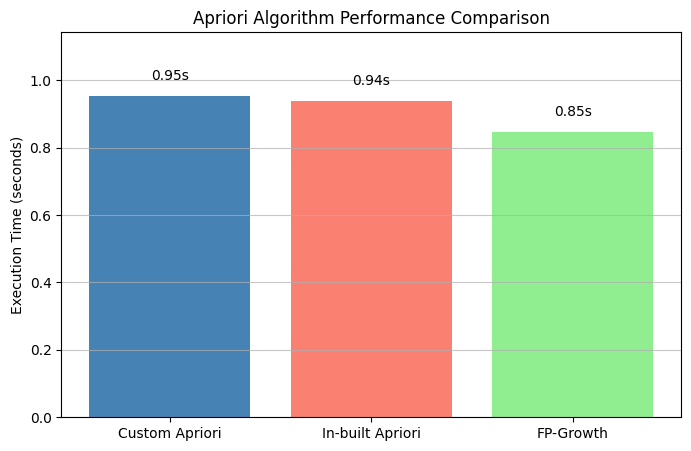

In [79]:
import matplotlib.pyplot as plt

# Get the results from the comparison
# algorithm_times = results # This line is causing the error

# Re-run the comparison to get the correct algorithm times
# We need to ensure that the 'compare_algorithms' function returns only the times dictionary
# Assuming 'compare_algorithms' is defined in a previous cell and returns the dictionary of times

# Call the comparison function and get only the timing results
algorithm_times, _, _ = compare_algorithms(transactions, df_encoded, min_support=min_support, max_length=max_length)


# Prepare data for plotting
algorithms = list(algorithm_times.keys())
times = list(algorithm_times.values())

# Create the bar chart
plt.figure(figsize=(8, 5))
plt.bar(algorithms, times, color=['steelblue', 'salmon', 'lightgreen'])
plt.ylabel("Execution Time (seconds)")
plt.title("Apriori Algorithm Performance Comparison")
plt.ylim(0, max(times) * 1.2)  # Add some padding above the tallest bar
plt.grid(axis='y', alpha=0.7)

# Add text labels for the times on top of the bars
for i, time in enumerate(times):
    plt.text(i, time + (max(times) * 0.05), f"{time:.2f}s", ha='center')

plt.show()

In [ ]:
# ---------------------------------------------------------------
# Generate Association Rules (built-in)
# ---------------------------------------------------------------
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
print(f"\n Generated {len(rules)} association rules")

# Show top 10 rules by lift
print("\n===== TOP 10 ASSOCIATION RULES =====")
print(
    rules.sort_values("lift", ascending=False)
         .head(10)
         .loc[:, ["antecedents", "consequents", "support", "confidence", "lift"]]
)


✅ Generated 413 association rules

===== TOP 10 ASSOCIATION RULES =====
                      antecedents             consequents   support  \
387              (art, comicbook)  (preview, comic, ncbd)  0.005562   
335              (art, comicbook)        (preview, comic)  0.005562   
348              (art, comicbook)           (ncbd, comic)  0.005562   
344       (art, comic, comicbook)                  (ncbd)  0.005562   
298           (review, comicbook)  (preview, comic, ncbd)  0.005562   
43                  (art, review)        (preview, comic)  0.005562   
291    (comic, review, comicbook)         (preview, ncbd)  0.005562   
290  (preview, review, comicbook)           (comic, ncbd)  0.005562   
259           (review, comicbook)           (ncbd, comic)  0.005562   
268  (preview, review, comicbook)                  (ncbd)  0.005562   

     confidence        lift  
387         1.0  170.564103  
335         1.0  170.564103  
348         1.0  170.564103  
344         1.0  170.5641

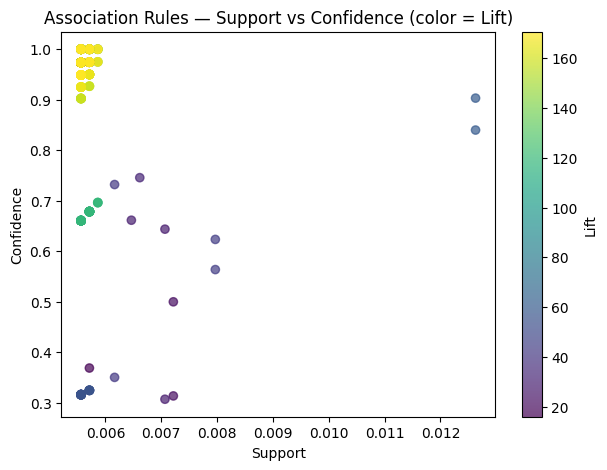

In [81]:
plt.figure(figsize=(7,5))
plt.scatter(rules["support"], rules["confidence"], c=rules["lift"], cmap="viridis", alpha=0.7)
plt.colorbar(label="Lift")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules — Support vs Confidence (color = Lift)")
plt.show()

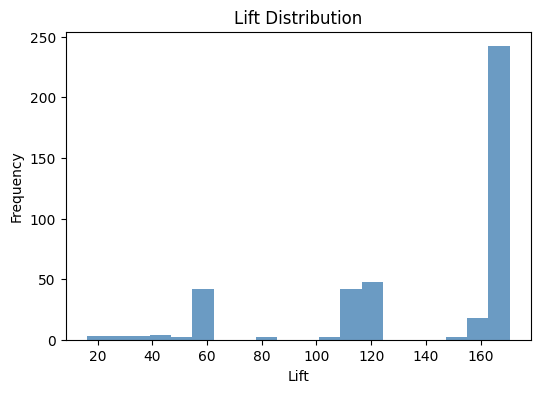

In [82]:
plt.figure(figsize=(6,4))
plt.hist(rules["lift"], bins=20, color="steelblue", alpha=0.8)
plt.xlabel("Lift")
plt.ylabel("Frequency")
plt.title("Lift Distribution")
plt.show()

In [ ]:
# ================================================================
# Association Rule Evaluation + Tweet Matching + Visualization
# ================================================================
import pandas as pd
import matplotlib.pyplot as plt

def display_tweets_matching_rules(df, rules, top_n=10):
    """
    Display trending tweets that match top association rules found by Apriori algorithm.

    Parameters:
        df (DataFrame): DataFrame containing tweet data
        rules (DataFrame): Association rules DataFrame from mlxtend.association_rules()
        top_n (int): Number of top tweets to display per rule
    """
    print("\n===== TRENDING TWEETS MATCHING ASSOCIATION RULES =====\n")

    # Compute engagement score (weighted)
    if 'retweetcount' in df.columns and 'favoritecount' in df.columns:
        df['engagement_score'] = df['retweetcount'] + 0.5 * df['favoritecount']
    elif 'retweetcount' in df.columns:
        df['engagement_score'] = df['retweetcount']
    else:
        df['engagement_score'] = df['hashtags'].apply(len)

    # Select top 5 rules by lift
    top_rules = rules.sort_values("lift", ascending=False).head(5)

    for i, (_, rule) in enumerate(top_rules.iterrows(), 1):
        antecedent = list(rule['antecedents'])
        consequent = list(rule['consequents'])

        print(f"\nRule #{i}: {set(antecedent)} => {set(consequent)}")
        print(f"Support: {rule['support']:.4f}, Confidence: {rule['confidence']:.4f}, Lift: {rule['lift']:.4f}")
        print("-" * 60)

        # Find tweets containing both antecedent and consequent hashtags
        matching_tweets = df[df['hashtags'].apply(
            lambda tags: all(tag in tags for tag in antecedent) and
                         all(tag in tags for tag in consequent)
        )]

        if not matching_tweets.empty:
            trending = matching_tweets.sort_values('engagement_score', ascending=False).head(top_n)
            print(f"Found {len(matching_tweets)} tweets matching this rule. Showing top {len(trending)}:")

            for j, (_, tweet) in enumerate(trending.iterrows(), 1):
                print(f"\nTweet #{j}:")
                text = tweet.get('text', '')
                print(f"Text: {text[:100]}..." if len(text) > 100 else f"Text: {text}")

                hashtags = ', '.join(f"#{h}" for h in tweet['hashtags'])
                print(f"Hashtags: {hashtags}")

                if 'retweetcount' in tweet:
                    print(f"Retweets: {tweet['retweetcount']}")
                if 'favoritecount' in tweet:
                    print(f"Favorites: {tweet['favoritecount']}")
                if 'tweetcreatedts' in tweet:
                    print(f"Created: {tweet['tweetcreatedts']}")
                print("-" * 40)
        else:
            print("No tweets found matching this rule.")
            print("Checking for antecedent-only matches...")

            # Show antecedent-only tweets
            ante_matches = df[df['hashtags'].apply(lambda tags: all(tag in tags for tag in antecedent))]
            if not ante_matches.empty:
                print(f"Found {len(ante_matches)} tweets containing only {set(antecedent)}.")


def visualize_rule_distribution(df, rules):
    """
    Visualize number of tweets matching top association rules over time.
    """
    if 'tweetcreatedts' not in df.columns:
        print("❌ Cannot visualize distribution — 'tweetcreatedts' not found.")
        return

    df['datetime'] = pd.to_datetime(df['tweetcreatedts'])
    df['date'] = df['datetime'].dt.date

    top_rules = rules.sort_values("lift", ascending=False).head(5)
    dates = sorted(df['date'].unique())
    rule_counts = {i: [] for i in range(len(top_rules))}

    for date in dates:
        day_tweets = df[df['date'] == date]
        for i, (_, rule) in enumerate(top_rules.iterrows()):
            antecedent = list(rule['antecedents'])
            consequent = list(rule['consequents'])
            count = day_tweets[day_tweets['hashtags'].apply(
                lambda tags: all(tag in tags for tag in antecedent) and
                             all(tag in tags for tag in consequent)
            )].shape[0]
            rule_counts[i].append(count)

    plt.figure(figsize=(12, 6))
    for i, counts in rule_counts.items():
        rule = top_rules.iloc[i]
        label = f"{set(rule['antecedents'])} => {set(rule['consequents'])}"
        plt.plot(dates, counts, marker='o', label=label)

    plt.title("Tweet Matches Over Time for Top Association Rules")
    plt.xlabel("Date")
    plt.ylabel("Number of Matching Tweets")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------
# Comprehensive Analysis Wrapper
# ---------------------------------------------------------------
def comprehensive_twitter_trend_analysis(df, transactions, min_support=0.005, min_confidence=0.3):
    """
    Full Twitter Trend Analysis: Apriori + Rule Mining + Visualization
    """
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules
    import time

    print("\n========== TWITTER TREND ANALYSIS ==========\n")

    # One-hot encode transactions
    te = TransactionEncoder()
    df_encoded = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)

    # Run Apriori
    start = time.time()
    frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)
    end = time.time()


    

    # Generate rules
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
    print(f"Generated {len(rules)} rules.\n")

    # Display tweets for top rules
    display_tweets_matching_rules(df, rules)

    # Visualize rule trend over time
    # visualize_rule_distribution(df, rules)

    return {
        "frequent_itemsets": frequent_itemsets,
        "rules": rules
    }



# ---------------------------------------------------------------
# EXECUTION
# ---------------------------------------------------------------
if __name__ == "__main__":
    results = comprehensive_twitter_trend_analysis(G
        df, transactions,
        min_support=0.005,
        min_confidence=0.3
    )



========== TWITTER TREND ANALYSIS ==========

✅ Apriori completed in 1.14s with 223 itemsets.
✅ Generated 1321 rules.


===== TRENDING TWEETS MATCHING ASSOCIATION RULES =====


Rule #1: {'comicbook', 'ncbd'} => {'comicbooknew', 'preview', 'review', 'comic'}
Support: 0.0051, Confidence: 0.8947, Lift: 175.0526
------------------------------------------------------------
Found 34 tweets matching this rule. Showing top 10:

Tweet #1:
Text: Star Wars: Darth Vader #30 Preview #MARVEL #marvelcomics #comics #comicbooks #news #mcu #NCBD #comic...
Hashtags: #marvel, #marvelcom, #comic, #comicbook, #mcu, #ncbd, #comicbooknew, #amazon, #preview, #review, #starwar, #darthvad, #vader, #starwarscom
Retweets: 1
Created: 2023-01-07 00:22:05
----------------------------------------

Tweet #2:
Text: Avengers #64 Review #avengers #MARVEL #marvelcomics #comics #comicbooks #news #mcu #art #info #NCBD ...
Hashtags: #aveng, #marvel, #marvelcom, #comic, #comicbook, #mcu, #art, #ncbd, #comicbooknew, #preview, 

In [84]:
def find_most_relevant_tweets(df, rules_df, top_n=10):
    """
    Identify tweets that match the highest number of association rules,
    rank them by rule match count and engagement score.

    Parameters:
    df (DataFrame): DataFrame containing tweets and hashtags
    rules_df (DataFrame): Association rules DataFrame from mlxtend.association_rules()
    top_n (int): Number of top tweets to display
    """
    print("\n===== MOST RELEVANT TRENDING TWEETS (Based on Multiple Rules) =====\n")

    # Ensure engagement_score exists
    if 'engagement_score' not in df.columns:
        if 'retweetcount' in df.columns and 'favoritecount' in df.columns:
            df['engagement_score'] = df['retweetcount'] + df['favoritecount'] * 0.5
        elif 'retweetcount' in df.columns:
            df['engagement_score'] = df['retweetcount']
        else:
            df['engagement_score'] = df['hashtags'].apply(len)

    # Prepare rules: convert antecedents and consequents to lists
    if isinstance(rules_df, pd.DataFrame):
        rules = [
            (list(rule['antecedents']), list(rule['consequents']))
            for _, rule in rules_df.iterrows()
        ]
    else:
        # If already a list of tuples
        rules = [(r[0], r[1]) for r in rules_df]

    # Initialize rule match count
    df['rule_match_count'] = 0

    # Count how many rules each tweet satisfies
    for antecedent, consequent in rules:
        mask = df['hashtags'].apply(
            lambda tags: all(tag in tags for tag in antecedent)
            and all(tag in tags for tag in consequent)
        )
        df.loc[mask, 'rule_match_count'] += 1

    # Keep only tweets that matched at least one rule
    matched_df = df[df['rule_match_count'] > 0].copy()

    if matched_df.empty:
        print("No tweets matched any association rules.")
        return

    # Sort by rule match count and engagement
    top_tweets = matched_df.sort_values(
        ['rule_match_count', 'engagement_score'],
        ascending=[False, False]
    ).head(top_n)

    # Display results
    for i, (_, tweet) in enumerate(top_tweets.iterrows(), 1):
        print(f"\nTweet #{i}")
        print(f"Matched Rules: {tweet['rule_match_count']}")
        print(f"Engagement Score: {tweet['engagement_score']:.1f}")

        if 'text' in tweet:
            text = tweet['text']
            print(f"Text: {text[:100]}..." if len(text) > 100 else f"Text: {text}")

        print("Hashtags:", ', '.join([f"#{t}" for t in tweet['hashtags']]))

        if 'retweetcount' in tweet:
            print(f"Retweets: {tweet['retweetcount']}")
        if 'favoritecount' in tweet:
            print(f"Favorites: {tweet['favoritecount']}")
        if 'tweetcreatedts' in tweet:
            print(f"Created: {tweet['tweetcreatedts']}")

        print("-" * 50)


In [85]:
# Call find_most_relevant_tweets
find_most_relevant_tweets(df, rules)


===== MOST RELEVANT TRENDING TWEETS (Based on Multiple Rules) =====


Tweet #1
Matched Rules: 402
Engagement Score: 1.0
Text: Avengers #64 Review #avengers #MARVEL #marvelcomics #comics #comicbooks #news #mcu #art #info #NCBD ...
Hashtags: #aveng, #marvel, #marvelcom, #comic, #comicbook, #mcu, #art, #ncbd, #comicbooknew, #preview, #review, #ironman, #thor, #hulk, #captainamerica, #avengersassembl, #amazon
Retweets: 1
Created: 2023-01-07 01:00:00
--------------------------------------------------

Tweet #2
Matched Rules: 402
Engagement Score: 1.0
Text: I Am Batman #17 Preview #jacefox #iambatman #johnridley #DCEU #dccomics #comics #comicbooks #news #d...
Hashtags: #jacefox, #iambatman, #johnridley, #dceu, #dccomic, #comic, #comicbook, #dcu, #dcuunivers, #art, #ncbd, #amazon, #comicbooknew, #preview, #review, #batman, #darkknight, #capedcrusad
Retweets: 1
Created: 2023-01-07 11:00:30
--------------------------------------------------

Tweet #3
Matched Rules: 402
Engagement Score: 1.0
Te